In [11]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the shared code in /src importable, whichever folder the notebook runs from
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "src"))

from common import load_team_matches, PROCESSED, FIGURES, RESULTS, PRIOR_GOALS

pd.set_option("display.width", 150)

In [12]:
tm = load_team_matches()
print(f"Team-match rows: {len(tm)} | teams: {tm['Team'].nunique()} | matches: {tm['Match_ID'].nunique()}")

# Points earned in each match (score in play; shoot-outs ignored): win 3, draw 1, loss 0
tm["Points"] = np.select([tm["Goals_For"] > tm["Goals_Against"],
                          tm["Goals_For"] == tm["Goals_Against"]], [3, 1], default=0)

tm[tm["Team"] == "Spain"][["Round", "Date", "Opponent", "Goals_For", "Goals_Against", "Points"]]

Team-match rows: 208 | teams: 48 | matches: 104


,Round,Date,Opponent,Goals_For,Goals_Against,Points
173,Group stage,2026-06-15,Cabo Verde,0,0,1
174,Group stage,2026-06-21,Saudi Arabia,4,0,3
175,Group stage,2026-06-26,Uruguay,1,0,3
176,Round of 32,2026-07-02,Austria,3,0,3
177,Round of 16,2026-07-06,Portugal,1,0,3
178,Quarter-finals,2026-07-10,Belgium,2,1,3
179,Semi-finals,2026-07-14,France,2,0,3
180,Final,2026-07-19,Argentina,1,0,3


In [13]:
g = tm.groupby("Team")

tm["Matches_Played_Before"] = g.cumcount()          # 0 for a team's first match
for col, tag in [("Goals_For", "GF"), ("Goals_Against", "GA"), ("Points", "Pts")]:
    # cumsum() includes the current match, so subtract it: "everything BEFORE this match"
    tm[f"Cum_{tag}_Before"] = g[col].cumsum() - tm[col]

n = tm["Matches_Played_Before"]
has_history = n > 0

tm[tm["Team"] == "Germany"][["Date", "Opponent", "Goals_For", "Goals_Against",
                             "Matches_Played_Before", "Cum_GF_Before", "Cum_GA_Before"]]

,Date,Opponent,Goals_For,Goals_Against,Matches_Played_Before,Cum_GF_Before,Cum_GA_Before
92,2026-06-14,Curacao,7,1,0,0,0
93,2026-06-20,Cote d'Ivoire,2,1,1,7,1
94,2026-06-25,Ecuador,1,2,2,9,2
95,2026-06-29,Paraguay,1,1,3,10,4


In [14]:
# --- Raw averages: undefined (NaN) for a team's opening match ---
n_safe = n.replace(0, np.nan)
tm["Avg_GF_Raw"] = tm["Cum_GF_Before"] / n_safe
tm["Avg_GA_Raw"] = tm["Cum_GA_Before"] / n_safe
tm["Avg_Pts_Raw"] = tm["Cum_Pts_Before"] / n_safe

# --- Shrunk averages: blend the team's record with a neutral prior ---
#   shrunk = (cumulative + K * prior) / (matches_played + K)
# K = weight of the prior in "virtual matches" (fixed in advance).
# At an opening match (n = 0) the value equals the prior exactly.
K = 2
PRIOR_PTS = 1.0             # an unknown team is assumed to draw on average
tm["Avg_GF_Before"] = (tm["Cum_GF_Before"] + K * PRIOR_GOALS) / (n + K)
tm["Avg_GA_Before"] = (tm["Cum_GA_Before"] + K * PRIOR_GOALS) / (n + K)
tm["Avg_Pts_Before"] = (tm["Cum_Pts_Before"] + K * PRIOR_PTS) / (n + K)
tm["Avg_GD_Before"] = tm["Avg_GF_Before"] - tm["Avg_GA_Before"]

tm[tm["Team"] == "Germany"][["Matches_Played_Before", "Avg_GF_Raw", "Avg_GF_Before"]].round(2)

,Matches_Played_Before,Avg_GF_Raw,Avg_GF_Before
92,0,NaN,1.35
93,1,7.00,3.23
94,2,4.50,2.92
95,3,3.33,2.54


In [15]:
# For EVERY row, recompute the totals the slow, obvious way: look at that team's
# matches with a strictly earlier date. Any look-ahead bug would fail here.
bad = 0
for i, row in tm.iterrows():
    earlier = tm[(tm["Team"] == row["Team"]) & (tm["Date"] < row["Date"])]
    ok = (len(earlier) == row["Matches_Played_Before"]
          and earlier["Goals_For"].sum() == row["Cum_GF_Before"]
          and earlier["Goals_Against"].sum() == row["Cum_GA_Before"]
          and earlier["Points"].sum() == row["Cum_Pts_Before"])
    bad += (not ok)

assert bad == 0, f"{bad} rows failed the look-ahead check"
assert tm.groupby(["Team", "Date"]).size().max() == 1, "a team played twice on one day"
print(f"Look-ahead check passed for all {len(tm)} rows (brute force = vectorised).")

Look-ahead check passed for all 208 rows (brute force = vectorised).


Matches already played before this one -> number of team-match rows
Matches_Played_Before
0    48
1    48
2    48
3    32
4    16
5     8
6     4
7     4

Rows with NO history (opening matches): 48 of 208


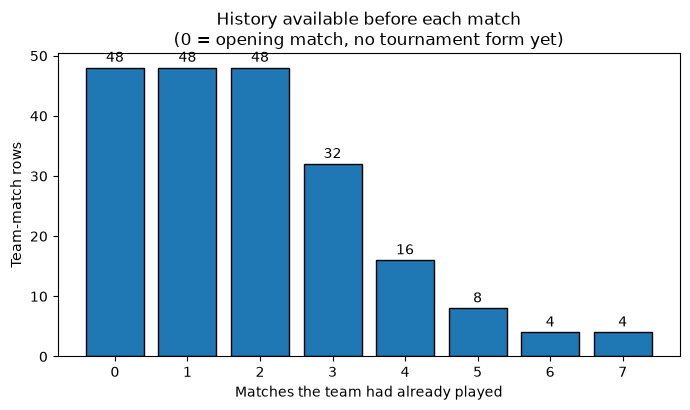

In [16]:
depth = n.value_counts().sort_index()
print("Matches already played before this one -> number of team-match rows")
print(depth.to_string())
print(f"\nRows with NO history (opening matches): {(~has_history).sum()} of {len(tm)}")

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(depth.index.astype(str), depth.values, edgecolor="black")
for x, v in zip(depth.index.astype(str), depth.values):
    ax.text(x, v + 1, str(v), ha="center")
ax.set_xlabel("Matches the team had already played")
ax.set_ylabel("Team-match rows")
ax.set_title("History available before each match\n(0 = opening match, no tournament form yet)")
plt.tight_layout()
plt.savefig(FIGURES / "arpan_history_depth.png", dpi=150)
plt.show()

In [17]:
# Summary of the features (rows that have some history)
tm.loc[has_history, ["Avg_GF_Raw", "Avg_GA_Raw", "Avg_Pts_Raw",
                     "Avg_GF_Before", "Avg_GA_Before"]].describe().T[["mean", "std", "min", "max"]].round(2)

,mean,std,min,max
Avg_GF_Raw,1.73,1.11,0.00,7.00
Avg_GA_Raw,1.27,1.10,0.00,7.00
Avg_Pts_Raw,1.66,1.02,0.00,3.00
Avg_GF_Before,1.57,0.52,0.68,3.23
Avg_GA_Before,1.27,0.50,0.39,3.23


In [18]:
# How strongly does a team's earlier scoring average relate to the goals it scores
# in THIS match? K = 0 is the raw average. Compared on the SAME rows (those with
# history). K was fixed at 2 in advance; this only checks the result is not
# sensitive to that choice.
sub = tm[has_history]
rows = []
for k in [0, 1, 2, 3, 5, 8, 12]:
    feat = (sub["Cum_GF_Before"] + k * PRIOR_GOALS) / (sub["Matches_Played_Before"] + k)
    rows.append({"K": k, "corr_with_goals_scored": np.corrcoef(feat, sub["Goals_For"])[0, 1]})

sens = pd.DataFrame(rows).round(3)
sens.to_csv(RESULTS / "arpan_shrinkage_sensitivity.csv", index=False)
print(f"n = {len(sub)} rows with history")
sens

n = 160 rows with history


,K,corr_with_goals_scored
0,0,0.111
1,1,0.120
2,2,0.124
3,3,0.125
4,5,0.126
5,8,0.127
6,12,0.127


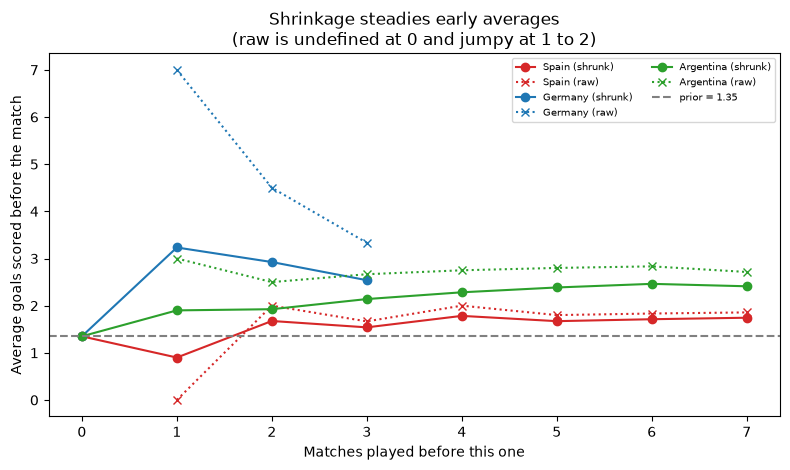

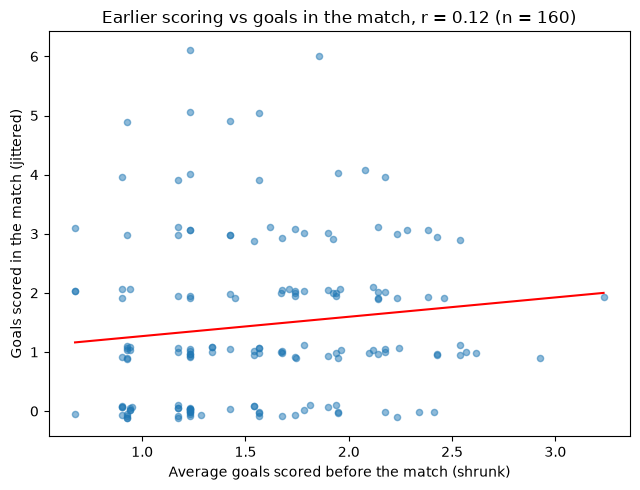

In [ ]:
# --- Chart 1: raw vs shrunk average for three teams ---
fig, ax = plt.subplots(figsize=(8, 4.8))
for team, colour in [("Spain", "tab:red"), ("Germany", "tab:blue"), ("Argentina", "tab:green")]:
    d = tm[tm["Team"] == team]
    ax.plot(d["Matches_Played_Before"], d["Avg_GF_Before"], "-o", color=colour, label=f"{team} (shrunk)")
    ax.plot(d["Matches_Played_Before"], d["Avg_GF_Raw"], ":x", color=colour, label=f"{team} (raw)")
ax.axhline(PRIOR_GOALS, color="grey", linestyle="--", label=f"prior = {PRIOR_GOALS}")
ax.set_xlabel("Matches played before this one")
ax.set_ylabel("Average goals scored before the match")
ax.set_title("Shrinkage steadies early averages\n(raw is undefined at 0 and jumpy at 1 to 2)")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(FIGURES / "arpan_raw_vs_shrunk.png", dpi=150)
plt.show()

# --- Chart 2: earlier scoring vs goals scored in the match ---
fig, ax = plt.subplots(figsize=(6.5, 5))
rng = np.random.default_rng(42)
jitter = rng.uniform(-0.12, 0.12, len(sub))s
ax.scatter(sub["Avg_GF_Before"], sub["Goals_For"] + jitter, alpha=0.5, s=20)
slope, intercept = np.polyfit(sub["Avg_GF_Before"], sub["Goals_For"], 1)
xs = np.linspace(sub["Avg_GF_Before"].min(), sub["Avg_GF_Before"].max(), 50)
ax.plot(xs, intercept + slope * xs, color="red")
r = np.corrcoef(sub["Avg_GF_Before"], sub["Goals_For"])[0, 1]
ax.set_xlabel("Average goals scored before the match (shrunk)")
ax.set_ylabel("Goals scored in the match (jittered)")
ax.set_title(f"Earlier scoring vs goals in the match, r = {r:.2f} (n = {len(sub)})")
plt.tight_layout()
plt.savefig(FIGURES / "arpan_scoring_vs_goals.png", dpi=150)
plt.show()

In [20]:
out_cols = ["Match_ID", "Team", "Matches_Played_Before",
            "Avg_GF_Before", "Avg_GA_Before", "Avg_GD_Before", "Avg_Pts_Before",
            "Avg_GF_Raw", "Avg_GA_Raw", "Avg_Pts_Raw"]
out = tm[out_cols].sort_values(["Match_ID", "Team"]).reset_index(drop=True)
out.round(4).to_csv(PROCESSED / "features_previous_performance.csv", index=False)
print(f"Saved {len(out)} rows -> data/clean/features_previous_performance.csv")
out.head(6)

Saved 208 rows -> data/clean/features_previous_performance.csv


,Match_ID,Team,Matches_Played_Before,Avg_GF_Before,Avg_GA_Before,Avg_GD_Before,Avg_Pts_Before,Avg_GF_Raw,Avg_GA_Raw,Avg_Pts_Raw
0,1,Mexico,0,1.35,1.35,0.0,1.0,NaN,NaN,NaN
1,1,South Africa,0,1.35,1.35,0.0,1.0,NaN,NaN,NaN
2,2,Czechia,0,1.35,1.35,0.0,1.0,NaN,NaN,NaN
3,2,Korea Republic,0,1.35,1.35,0.0,1.0,NaN,NaN,NaN
4,3,Bosnia-Herz,0,1.35,1.35,0.0,1.0,NaN,NaN,NaN
5,3,Canada,0,1.35,1.35,0.0,1.0,NaN,NaN,NaN
